In [ ]:
import numpy as np
import tensorflow as tf
import pandas as pd
from tqdm import tqdm
import os
from cv2 import imread, createCLAHE
import cv2
from glob import glob
%matplotlib inline
import matplotlib.pyplot as plt
from keras.models import Model
from keras.layers import Input, Conv2D, MaxPooling2D, Conv2DTranspose, concatenate
from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from keras import backend as K
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from IPython.display import clear_output
from tensorflow.keras.preprocessing.image import ImageDataGenerator

## Construção dos pares imagem-máscara

Neste experimento, cada radiografia precisa estar associada à sua respectiva máscara de segmentação pulmonar. Por isso, o primeiro passo consiste em verificar a correspondência entre os arquivos de imagem e suas máscaras, garantindo que apenas pares válidos sejam utilizados no treinamento.

In [2]:
caminho_imagens = "Lung Segmentation/CXR_png"
caminho_mascaras = "Lung Segmentation/masks"

caminhos_completos = []
print("Verificando e pareando arquivos de imagem e máscara...")

for nome_imagem in tqdm(os.listdir(caminho_imagens)):
    if nome_imagem.endswith('.png'):
        nome_base = os.path.splitext(nome_imagem)[0]
        
        nome_mascara_esperado = f"{nome_base}_mask.png"
        
        caminho_imagem_completo = os.path.join(caminho_imagens, nome_imagem)
        caminho_mascara_completo = os.path.join(caminho_mascaras, nome_mascara_esperado)
        
        if os.path.exists(caminho_mascara_completo):
            caminhos_completos.append((caminho_imagem_completo, caminho_mascara_completo))

print(f"\nOperação concluída. Encontrado {len(caminhos_completos)} pares de imagem/máscara válidos.")

Verificando e pareando arquivos de imagem e máscara...


100%|████████████████████████████████████████████████████████████████████████████████| 800/800 [00:00<00:00, 963.11it/s]


Operação concluída. Encontrado 566 pares de imagem/máscara válidos.


In [3]:
caminhos_treino_val, caminhos_teste = train_test_split(
    caminhos_completos, 
    test_size=0.1, 
    random_state=42
)
caminhos_treino, caminhos_val = train_test_split(
    caminhos_treino_val, 
    test_size=0.1, 
    random_state=42
)

print(f"Divisão de dados concluída:")
print(f"- Conjunto de Treino:   {len(caminhos_treino)} imagens")
print(f"- Conjunto de Validação: {len(caminhos_val)} imagens")
print(f"- Conjunto de Teste:     {len(caminhos_teste)} imagens")

def carregar_dados_de_caminhos(lista_de_pares, tamanho_img):
    lista_imagens = []
    lista_mascaras = []

    print(f"\nCarregando {len(lista_de_pares)} imagens de {tamanho_img}x{tamanho_img} pixels...")
    for caminho_img, caminho_mascara in tqdm(lista_de_pares):
        img = cv2.imread(caminho_img, cv2.IMREAD_GRAYSCALE)
        mascara = cv2.imread(caminho_mascara, cv2.IMREAD_GRAYSCALE)

        img_redimensionada = cv2.resize(img, (tamanho_img, tamanho_img))
        mascara_redimensionada = cv2.resize(mascara, (tamanho_img, tamanho_img))

        lista_imagens.append(img_redimensionada)
        lista_mascaras.append(mascara_redimensionada)
    
    return np.array(lista_imagens), np.array(lista_mascaras)

Divisão de dados concluída:
- Conjunto de Treino:   458 imagens
- Conjunto de Validação: 51 imagens
- Conjunto de Teste:     57 imagens


## Visualização das imagens e máscaras

Antes do treinamento, realizamos uma inspeção visual de exemplos do dataset para verificar:
- alinhamento entre imagem e máscara
- qualidade das anotações
- consistência visual dos dados

In [4]:
def plotar_mascaras_melhorado(imagens, mascaras, n_exemplos=6):
    n_exemplos = min(n_exemplos, len(imagens))
    
    fig, axes = plt.subplots(n_exemplos, 2, figsize=(8, 4 * n_exemplos))
    
    if n_exemplos == 1:
        axes = [axes]

    # fig.suptitle("Exemplos de Imagens e Máscaras", fontsize=16)

    for i in range(n_exemplos):
        img = np.squeeze(imagens[i])
        mascara = np.squeeze(mascaras[i])
        
        axes[i, 0].imshow(img, cmap='gray')
        axes[i, 0].set_title(f"Imagem de Entrada {i+1}")
        axes[i, 0].axis('off') 
        
        axes[i, 1].imshow(mascara, cmap='gray')
        axes[i, 1].set_title(f"Máscara {i+1}")
        axes[i, 1].axis('off') 

    plt.tight_layout()
    plt.show()


Carregando 458 imagens de 512x512 pixels...


100%|█████████████████████████████████████████████████████████████████████████████████| 458/458 [01:49<00:00,  4.18it/s]



Carregando 51 imagens de 512x512 pixels...


100%|███████████████████████████████████████████████████████████████████████████████████| 51/51 [00:12<00:00,  3.93it/s]



Carregando 57 imagens de 512x512 pixels...


100%|███████████████████████████████████████████████████████████████████████████████████| 57/57 [00:14<00:00,  3.92it/s]



Formatos dos arrays resultantes (shape):
X_treino: (458, 512, 512), y_treino: (458, 512, 512)
X_val:    (51, 512, 512), y_val:    (51, 512, 512)
X_teste:  (57, 512, 512), y_teste:  (57, 512, 512)

Visualizando alguns exemplos do conjunto de treino...


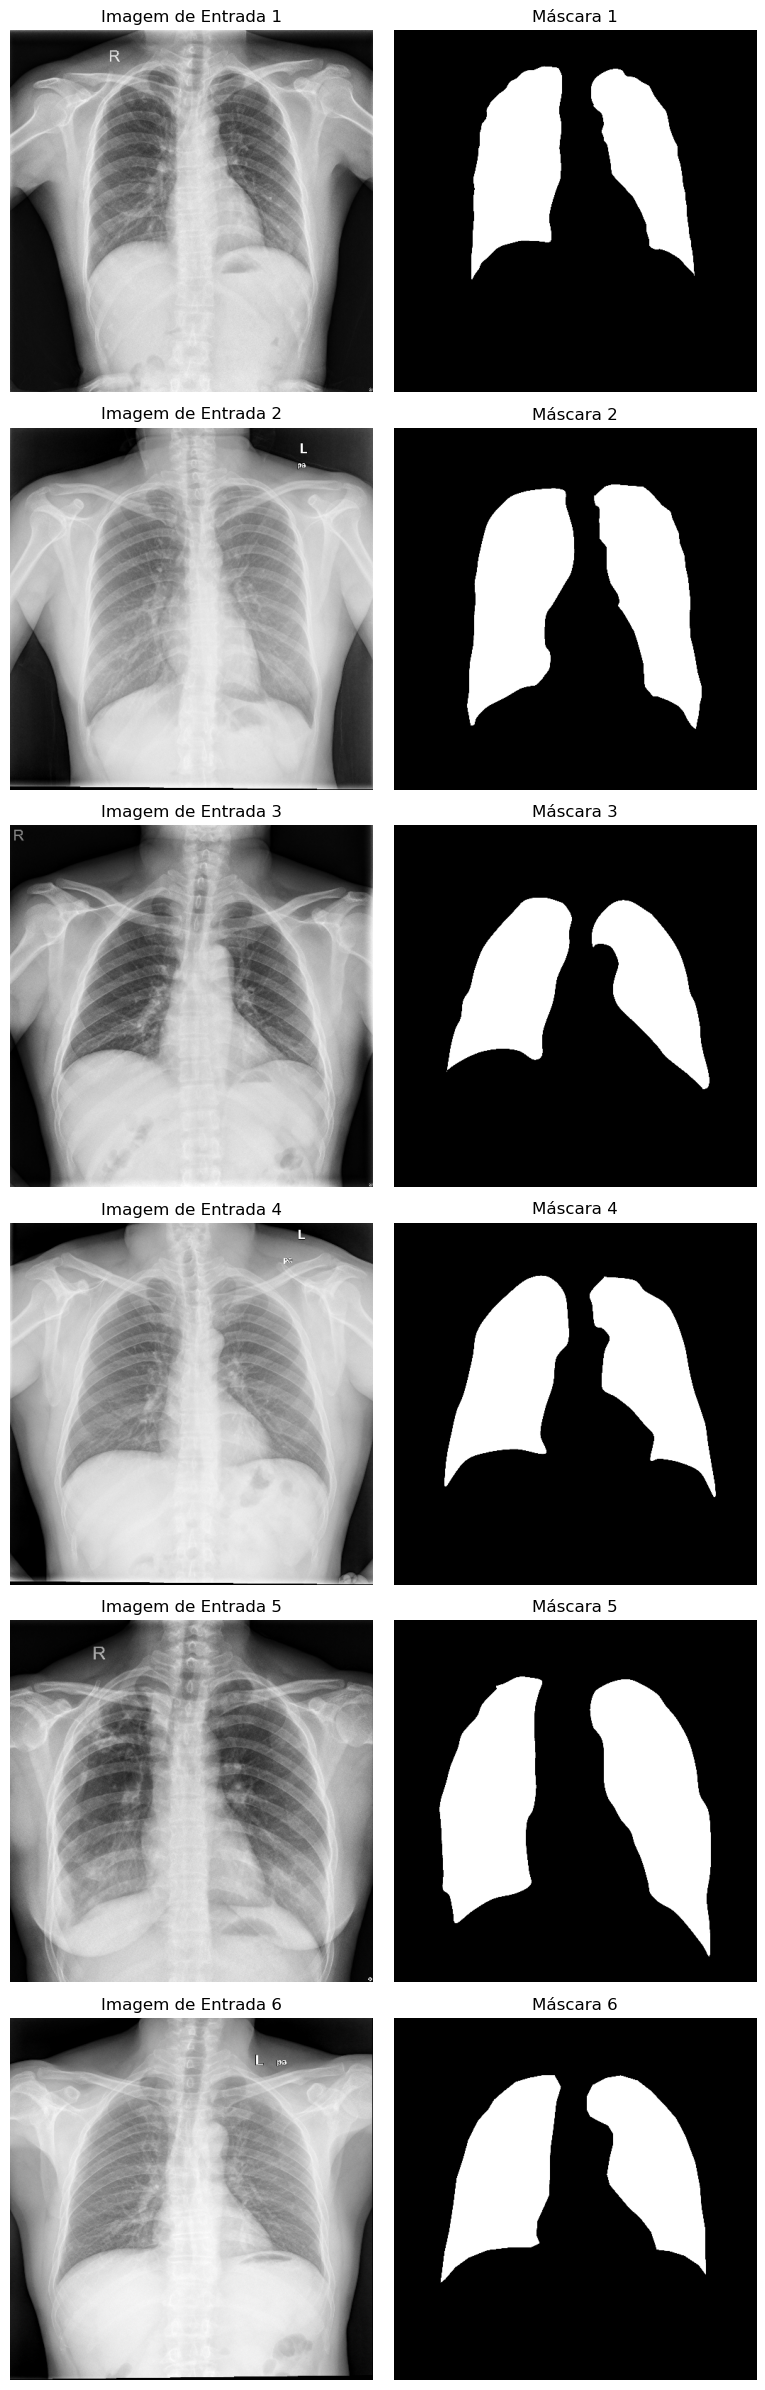

In [5]:
dimensao = 512 

X_treino, y_treino = carregar_dados_de_caminhos(caminhos_treino, dimensao)
X_val, y_val = carregar_dados_de_caminhos(caminhos_val, dimensao)
X_teste, y_teste = carregar_dados_de_caminhos(caminhos_teste, dimensao)

print("\nFormatos dos arrays resultantes (shape):")
print(f"X_treino: {X_treino.shape}, y_treino: {y_treino.shape}")
print(f"X_val:    {X_val.shape}, y_val:    {y_val.shape}")
print(f"X_teste:  {X_teste.shape}, y_teste:  {y_teste.shape}")

print("\nVisualizando alguns exemplos do conjunto de treino...")
plotar_mascaras_melhorado(X_treino, y_treino)

In [6]:
X_treino = X_treino.reshape(len(X_treino), dimensao, dimensao, 1)
y_treino = y_treino.reshape(len(y_treino), dimensao, dimensao, 1)

X_val = X_val.reshape(len(X_val), dimensao, dimensao, 1)
y_val = y_val.reshape(len(y_val), dimensao, dimensao, 1)

X_teste = X_teste.reshape(len(X_teste), dimensao, dimensao, 1)
y_teste = y_teste.reshape(len(y_teste), dimensao, dimensao, 1)

# Verificação de shapes para todos os conjuntos
assert X_treino.shape == y_treino.shape
assert X_val.shape == y_val.shape
assert X_teste.shape == y_teste.shape

print("Dimensão do canal adicionada com sucesso a todos os conjuntos.")
print(f"Novo shape de X_treino: {X_treino.shape}")
print(f"Novo shape de X_val:    {X_val.shape}")
print(f"Novo shape de X_teste:  {X_teste.shape}")

Dimensão do canal adicionada com sucesso a todos os conjuntos.
Novo shape de X_treino: (458, 512, 512, 1)
Novo shape de X_val:    (51, 512, 512, 1)
Novo shape de X_teste:  (57, 512, 512, 1)


## Arquitetura U-Net

A arquitetura escolhida foi a U-Net, uma das redes mais clássicas e eficazes para segmentação de imagens biomédicas.

Sua estrutura em formato de encoder-decoder permite:
- capturar contexto em múltiplas escalas
- recuperar detalhes espaciais durante a reconstrução
- combinar informações profundas e superficiais por meio das skip connections

In [7]:
def iou_metric(y_true, y_pred, smooth=1):
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    union = tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) - intersection
    return (intersection + smooth) / (union + smooth)

def coef_dice(y_true, y_pred):
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    intersecao = tf.reduce_sum(y_true_f * y_pred_f)
    return (2. * intersecao + 1) / (tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + 1)

def perda_dice(y_true, y_pred):
    return -coef_dice(y_true, y_pred)

def unet(input_size=(256,256,1)):
    entradas = Input(input_size)
    
    conv1 = Conv2D(32, (3, 3), activation='relu', padding='same')(entradas)
    conv1 = Conv2D(32, (3, 3), activation='relu', padding='same')(conv1)
    pool1 = MaxPooling2D(pool_size=(2, 2))(conv1)

    conv2 = Conv2D(64, (3, 3), activation='relu', padding='same')(pool1)
    conv2 = Conv2D(64, (3, 3), activation='relu', padding='same')(conv2)
    pool2 = MaxPooling2D(pool_size=(2, 2))(conv2)

    conv3 = Conv2D(128, (3, 3), activation='relu', padding='same')(pool2)
    conv3 = Conv2D(128, (3, 3), activation='relu', padding='same')(conv3)
    pool3 = MaxPooling2D(pool_size=(2, 2))(conv3)

    conv4 = Conv2D(256, (3, 3), activation='relu', padding='same')(pool3)
    conv4 = Conv2D(256, (3, 3), activation='relu', padding='same')(conv4)
    pool4 = MaxPooling2D(pool_size=(2, 2))(conv4)

    conv5 = Conv2D(512, (3, 3), activation='relu', padding='same')(pool4)
    conv5 = Conv2D(512, (3, 3), activation='relu', padding='same')(conv5)

    up6 = concatenate([Conv2DTranspose(256, (2, 2), strides=(2, 2), padding='same')(conv5), conv4], axis=3)
    conv6 = Conv2D(256, (3, 3), activation='relu', padding='same')(up6)
    conv6 = Conv2D(256, (3, 3), activation='relu', padding='same')(conv6)

    up7 = concatenate([Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same')(conv6), conv3], axis=3)
    conv7 = Conv2D(128, (3, 3), activation='relu', padding='same')(up7)
    conv7 = Conv2D(128, (3, 3), activation='relu', padding='same')(conv7)

    up8 = concatenate([Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(conv7), conv2], axis=3)
    conv8 = Conv2D(64, (3, 3), activation='relu', padding='same')(up8)
    conv8 = Conv2D(64, (3, 3), activation='relu', padding='same')(conv8)

    up9 = concatenate([Conv2DTranspose(32, (2, 2), strides=(2, 2), padding='same')(conv8), conv1], axis=3)
    conv9 = Conv2D(32, (3, 3), activation='relu', padding='same')(up9)
    conv9 = Conv2D(32, (3, 3), activation='relu', padding='same')(conv9)

    conv10 = Conv2D(1, (1, 1), activation='sigmoid')(conv9)

    return Model(inputs=[entradas], outputs=[conv10])

## Compilação do modelo

O modelo foi compilado com o otimizador **Adam**, utilizando taxa de aprendizado inicial de `1e-4`.

Como função de perda, foi utilizada a perda baseada em Dice, enquanto as métricas monitoradas foram:
- coeficiente Dice
- acurácia binária

Embora a acurácia binária tenha sido registrada, o coeficiente Dice é mais representativo para a qualidade da segmentação.

In [9]:
modelo = unet(input_size=(512,512,1))
modelo.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss=perda_dice,
    metrics=[coef_dice, 'binary_accuracy']
)
modelo.summary()

I0000 00:00:1759707237.255533     475 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5561 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060, pci bus id: 0000:01:00.0, compute capability: 8.9


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 512, 512,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 512, 512,  │        320 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 512, 512,  │      9,248 │ conv2d[0][0]      │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 256, 256,  │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 256, 256,  │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 256, 256,  │     36,928 │ conv2d_2[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 128, 128,  │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 128, 128,  │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 128, 128,  │    147,584 │ conv2d_4[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 64, 64,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 64, 64,    │    295,168 │ max_pooling2d_2[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 64, 64,    │    590,080 │ conv2d_6[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 32, 32,    │          0 │ conv2d_7[0][0]    │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 32, 32,    │  1,180,160 │ max_pooling2d_3[… │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 32, 32,    │  2,359,808 │ conv2d_8[0][0]    │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, 64, 64,    │    524,544 │ conv2d_9[0][0]    │
│ (Conv2DTranspose)   │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 64, 64,    │          0 │ conv2d_transpose

 Total params: 7,759,521 (29.60 MB)

 Trainable params: 7,759,521 (29.60 MB)

 Non-trainable params: 0 (0.00 B)

## Estratégias de controle do treinamento

Para tornar o treinamento mais estável e eficiente, foram utilizados três callbacks:

- **ModelCheckpoint**: salva automaticamente os melhores pesos com base na perda de validação
- **ReduceLROnPlateau**: reduz a taxa de aprendizado quando o modelo deixa de melhorar
- **EarlyStopping**: interrompe o treinamento caso a validação permaneça estagnada por várias épocas

Essas estratégias ajudam a evitar overfitting e melhoram a convergência do modelo.

In [10]:
caminho_pesos = "cxr_reg_pesos.weights.h5"

checkpoint = ModelCheckpoint(caminho_pesos, monitor='val_loss', verbose=1,
                             save_best_only=True, mode='min', save_weights_only=True)

reduzir_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, 
                                patience=3, verbose=1, mode='min', 
                                min_delta=0.0001, cooldown=2, min_lr=1e-6)

early_stop = EarlyStopping(monitor='val_loss', mode='min', patience=15)

lista_callbacks = [checkpoint, early_stop, reduzir_lr]

In [ ]:
print("Aplicando pré-processamento...")

# Normalização
X_treino_norm = (X_treino - 127.0) / 127.0
y_treino_bin = (y_treino > 127).astype(np.float32)

X_val_norm = (X_val - 127.0) / 127.0
y_val_bin = (y_val > 127).astype(np.float32)

print("Pré-processamento concluído.")

# Data Augmentation
print("\nConfigurando o gerador de dados com Data Augmentation...")

data_gen_args = dict(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

mask_data_gen_args = dict(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

image_datagen = ImageDataGenerator(**data_gen_args)
mask_datagen = ImageDataGenerator(**mask_data_gen_args)

seed = 1
batch_size = 2

train_image_generator = image_datagen.flow(X_treino_norm, seed=seed, batch_size=batch_size)
train_mask_generator = mask_datagen.flow(y_treino_bin, seed=seed, batch_size=batch_size)

# Gerador correto
def train_generator():
    while True:
        imgs = next(train_image_generator)
        masks = next(train_mask_generator)
        yield imgs, masks

print("Configuração concluída. Iniciando o treinamento...")

historico = modelo.fit(
    train_generator(),
    steps_per_epoch=len(X_treino_norm) // batch_size,
    epochs=150,
    validation_data=(X_val_norm, y_val_bin),
    callbacks=lista_callbacks
)


## Análise dos resultados obtidos

Os gráficos mostram a evolução da loss, da acurácia binária e do coeficiente Dice ao longo do treinamento. Observa-se que o modelo apresenta convergência já nas primeiras épocas, com melhora inicial consistente nas métricas e posterior estabilização. Isso indica que a U-Net conseguiu aprender padrões relevantes para a segmentação pulmonar.

Os resultados no conjunto de validação foram elevados, com acurácia binária próxima de 97%–98% e coeficiente Dice em torno de 0.95. Esses valores sugerem boa sobreposição entre as máscaras previstas e as máscaras reais.

Nota-se que as métricas de validação ficaram significativamente melhores que as métricas de treino. Isso pode ser explicado pelo uso de data augmentation apenas no conjunto de treinamento, tornando as amostras de treino mais difíceis do que as de validação.

De forma geral, os resultados indicam que a arquitetura U-Net foi eficaz para a tarefa proposta, apresentando boa capacidade de segmentação pulmonar no conjunto de validação.

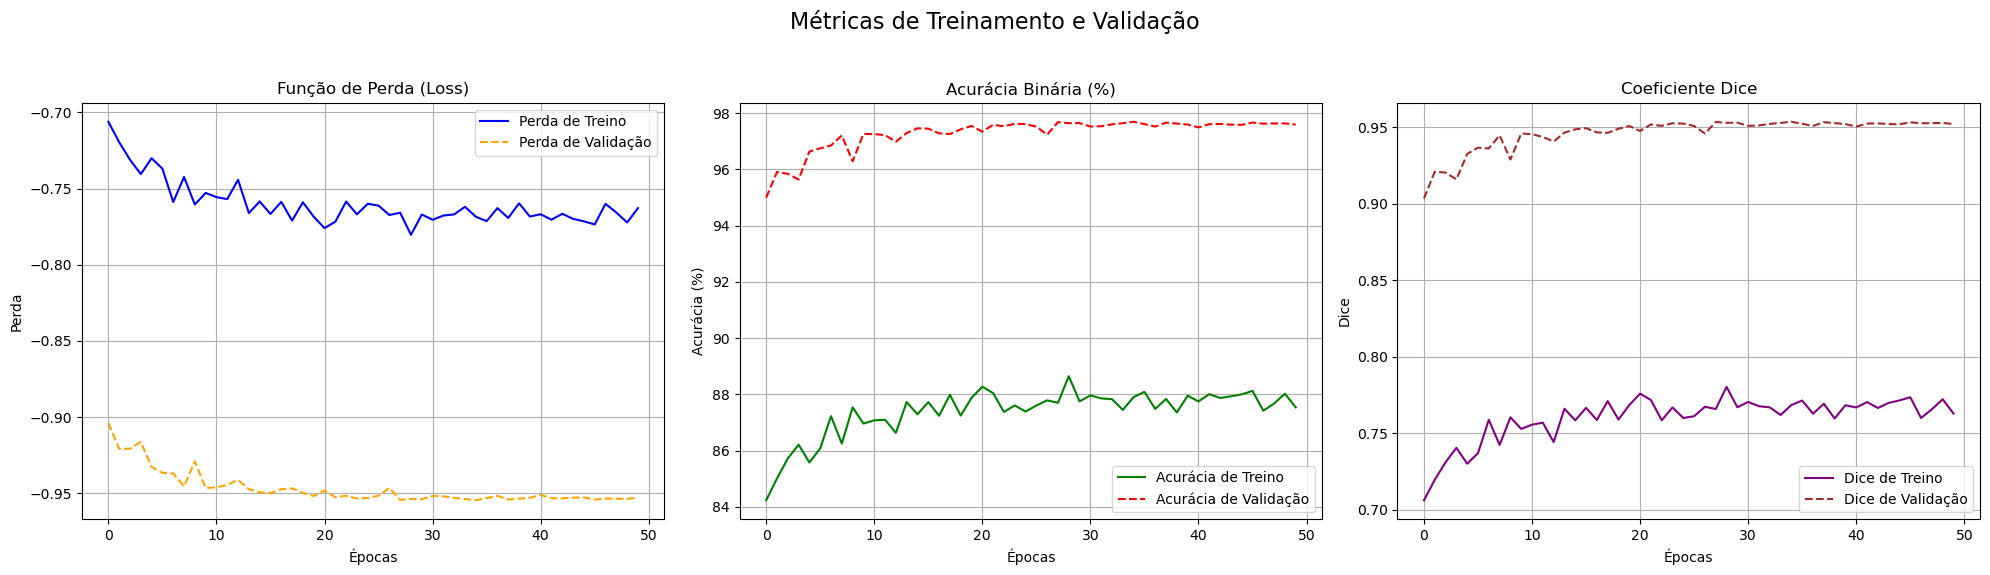

In [13]:
# 3 subplots
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Métricas de Treinamento e Validação', fontsize=16)

# Loss
ax1.plot(historico.history['loss'], '-', label='Perda de Treino', color='blue')
ax1.plot(historico.history['val_loss'], '--', label='Perda de Validação', color='orange')
ax1.set_title('Função de Perda (Loss)')
ax1.set_xlabel('Épocas')
ax1.set_ylabel('Perda')
ax1.legend()
ax1.grid(True)

# Acurácia
ax2.plot(100 * np.array(historico.history['binary_accuracy']), '-', label='Acurácia de Treino', color='green')
ax2.plot(100 * np.array(historico.history['val_binary_accuracy']), '--', label='Acurácia de Validação', color='red')
ax2.set_title('Acurácia Binária (%)')
ax2.set_xlabel('Épocas')
ax2.set_ylabel('Acurácia (%)')
ax2.legend()
ax2.grid(True)

# Coeficiente Dice
ax3.plot(historico.history['coef_dice'], '-', label='Dice de Treino', color='purple')
ax3.plot(historico.history['val_coef_dice'], '--', label='Dice de Validação', color='brown')
ax3.set_title('Coeficiente Dice')
ax3.set_xlabel('Épocas')
ax3.set_ylabel('Dice')
ax3.legend()
ax3.grid(True)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [ ]:
# ax4.plot(historico.history['iou_metric'], '-', label='IoU de Treino', color='cyan')
# ax4.plot(historico.history['val_iou_metric'], '--', label='IoU de Validação', color='magenta')
# ax4.set_title('Métrica IoU')
# ax4.set_xlabel('Épocas')
# ax4.set_ylabel('IoU')
# ax4.legend()
# ax4.grid(True)

# plt.tight_layout(rect=[0, 0.03, 1, 0.95])
# plt.show()

In [14]:
def criar_sobreposicao(imagem, mascara, cor):
    imagem_colorida = cv2.cvtColor(imagem, cv2.COLOR_GRAY2BGR)
    
    mascara_colorida = np.zeros_like(imagem_colorida)
    
    mascara_colorida[mascara > 0] = cor
    
    imagem_sobreposta = cv2.addWeighted(imagem_colorida, 1, mascara_colorida, 0.4, 0)
    
    return imagem_sobreposta

def criar_diferenca(imagem, mascara_real, mascara_prevista):
    imagem_colorida = cv2.cvtColor(imagem, cv2.COLOR_GRAY2BGR)

    falso_positivo = np.logical_and(mascara_real == 0, mascara_prevista > 0)
    falso_negativo = np.logical_and(mascara_real > 0, mascara_prevista == 0)
    
    imagem_colorida[falso_positivo] = (255, 0, 0)  # Azul para Falsos Positivos (BGR)
    imagem_colorida[falso_negativo] = (0, 0, 255) # Vermelho para Falsos Negativos (BGR)
    
    return imagem_colorida

26/26 ━━━━━━━━━━━━━━━━━━━━ 7s 124ms/step


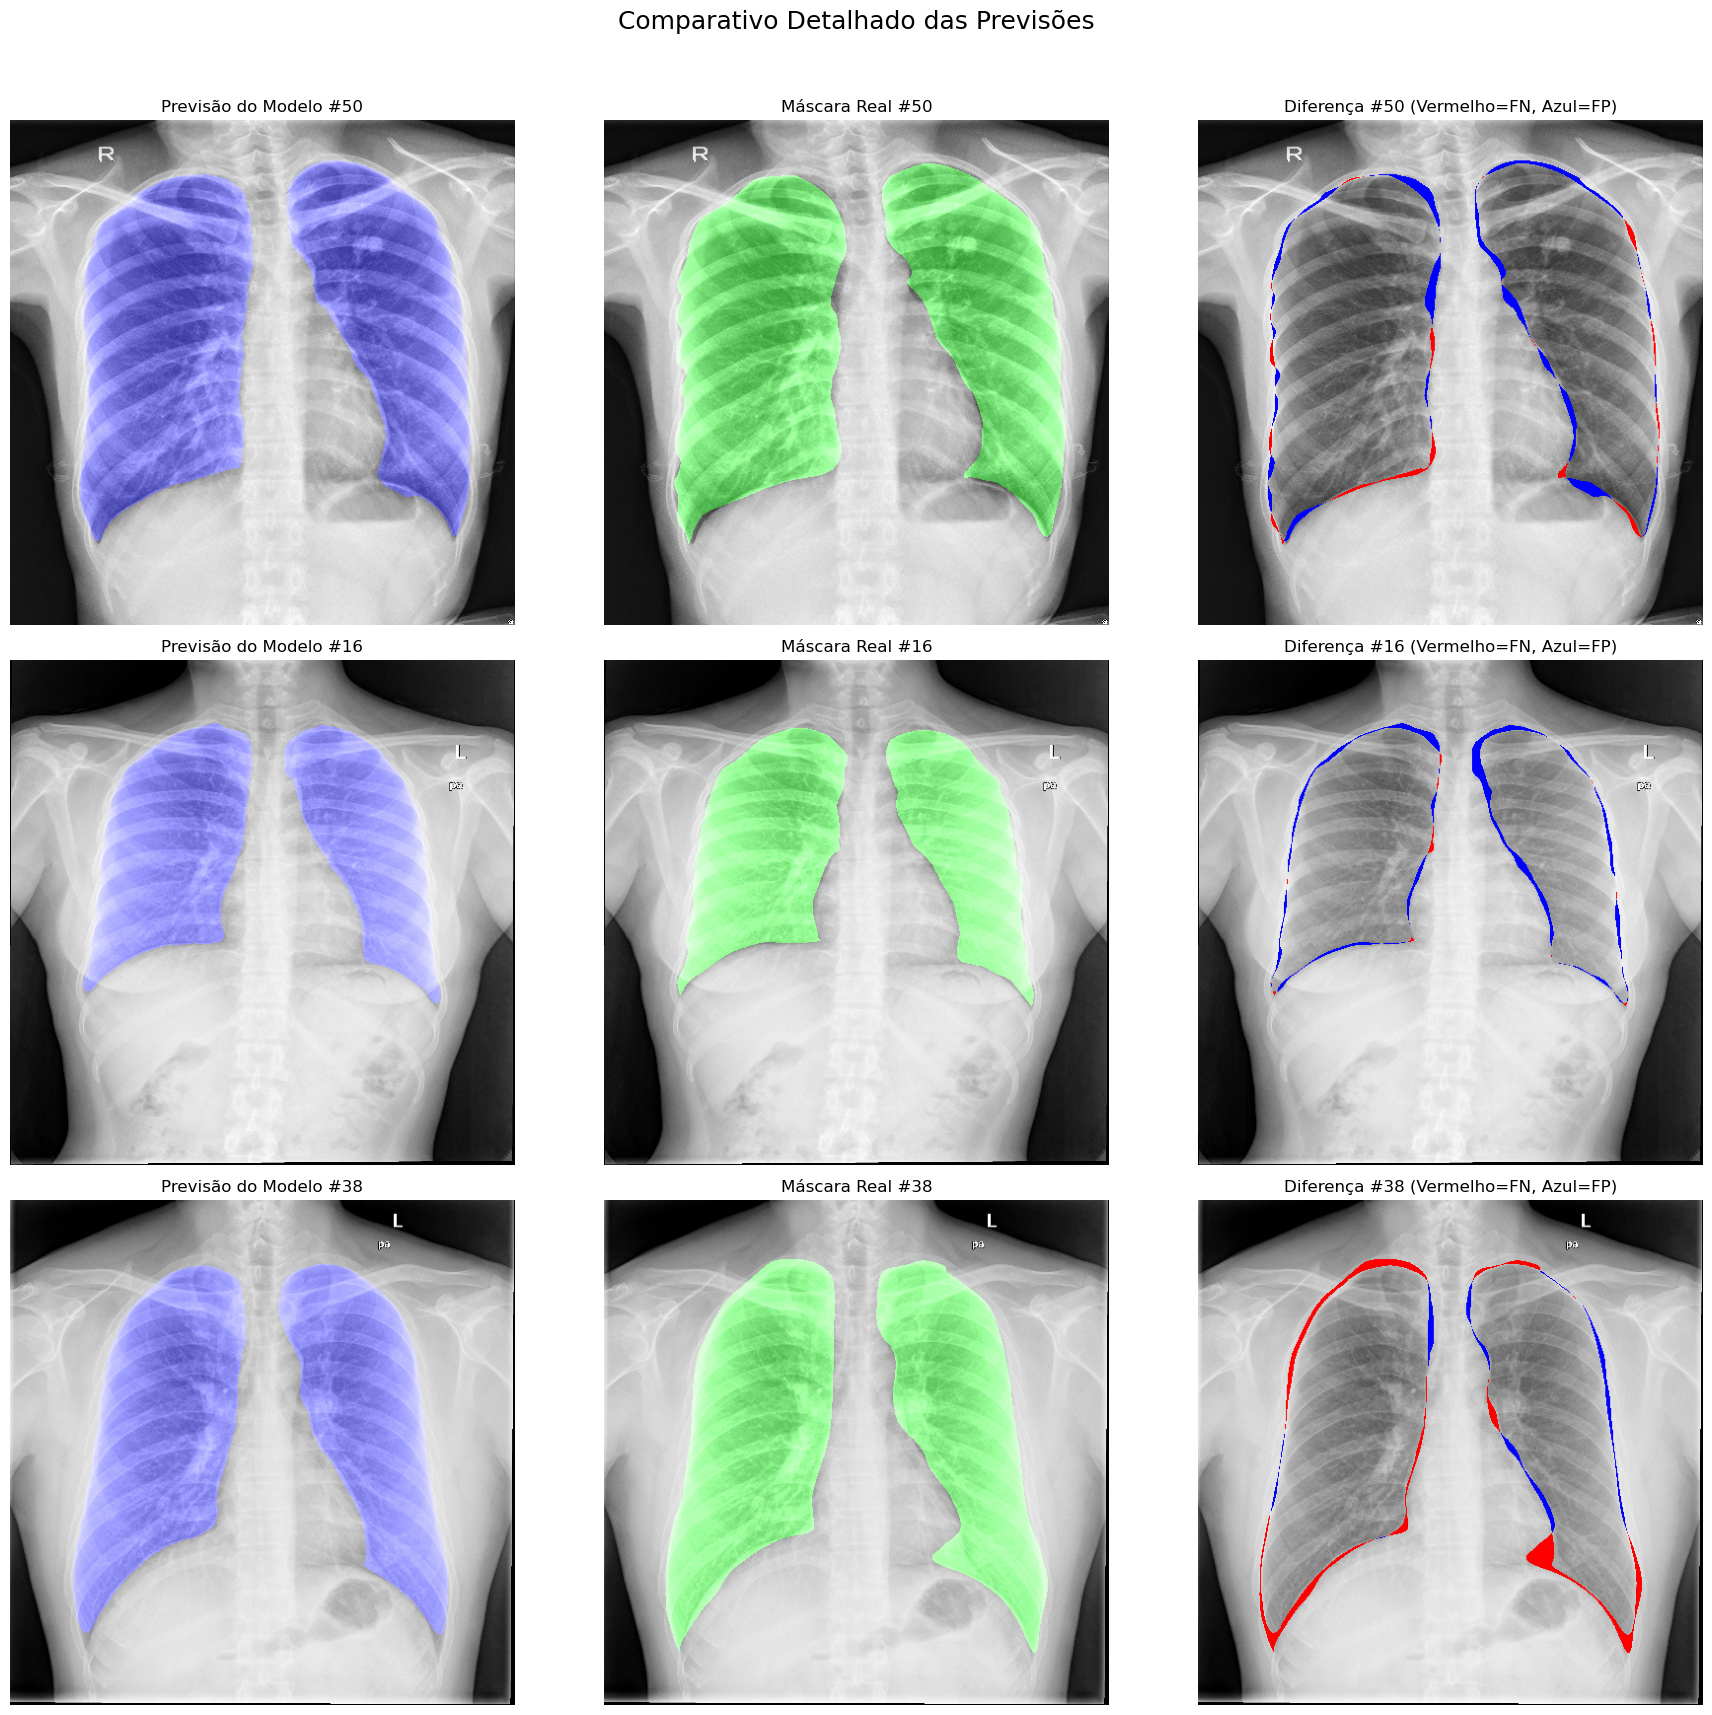

In [15]:
preds_val = modelo.predict(X_val_norm, batch_size=2)

preds_val_binarizada = (preds_val > 0.5).astype(np.uint8)

num_exemplos = 3
indices_aleatorios = np.random.choice(range(len(X_val_norm)), size=num_exemplos, replace=False)

plt.figure(figsize=(18, 6 * num_exemplos))
plt.suptitle("Comparativo Detalhado das Previsões", fontsize=18)

for i, idx in enumerate(indices_aleatorios):
    imagem_original = X_val[idx]
    mascara_real = y_val[idx]
    
    mascara_prevista = (preds_val_binarizada[idx] * 255).astype(np.uint8)
    
    sobreposicao_prevista = criar_sobreposicao(np.squeeze(imagem_original), np.squeeze(mascara_prevista), cor=(255, 0, 0)) # Azul
    plt.subplot(num_exemplos, 3, i * 3 + 1)
    plt.title(f"Previsão do Modelo #{idx}")
    plt.imshow(cv2.cvtColor(sobreposicao_prevista, cv2.COLOR_BGR2RGB))
    plt.axis('off')

    sobreposicao_real = criar_sobreposicao(np.squeeze(imagem_original), np.squeeze(mascara_real), cor=(0, 255, 0)) # Verde
    plt.subplot(num_exemplos, 3, i * 3 + 2)
    plt.title(f"Máscara Real #{idx}")
    plt.imshow(cv2.cvtColor(sobreposicao_real, cv2.COLOR_BGR2RGB))
    plt.axis('off')

    imagem_diferenca = criar_diferenca(np.squeeze(imagem_original), np.squeeze(mascara_real), np.squeeze(mascara_prevista))
    plt.subplot(num_exemplos, 3, i * 3 + 3)
    plt.title(f"Diferença #{idx} (Vermelho=FN, Azul=FP)")
    plt.imshow(cv2.cvtColor(imagem_diferenca, cv2.COLOR_BGR2RGB))
    plt.axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.show()